# 🏥 의료영상 및 의료인공지능 기초교육
### Medical Imaging & Medical AI — 학부생 교육 자료

---

## 📋 목차

| 파트 | 내용 | 유형 |
|------|------|------|
| **Part 1** | 의료영상 기초 이론 | 이론 + 시각화 |
| **Part 2** | 의료인공지능 이론 | 이론 + 다이어그램 |
| **Part 3** | 실습 예제 | 코딩 실습 |
| **Part 4** | Showcase 프로젝트 | 프로젝트 실습 |

---

> **👩‍🎓 대상:** 의료영상/AI를 처음 배우는 학부생  
> **🕐 예상 시간:** 약 6~8시간 (자기 페이스로)  
> **💻 요구사항:** Python 3.8+, 아래 셀 실행 후 시작

In [1]:
# ===== Clean environment (Student Version) =====
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
np.seterr(all='ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


## ⚙️ 0. 환경 설정 — 라이브러리 설치

In [ ]:
# Colab / Jupyter 공통 설정
import sys, subprocess, importlib.util

def ensure_package(pkg_name, import_name=None):
    import_name = import_name or pkg_name
    if importlib.util.find_spec(import_name) is None:
        print(f"📦 {pkg_name} 설치 중...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg_name])

# Colab에는 대부분 기본 포함되어 있으므로 꼭 필요한 것만 확인
ensure_package("opencv-python-headless", "cv2")
ensure_package("scikit-learn", "sklearn")

print("✅ Colab/Jupyter 기본 환경 점검 완료!")
print("💡 TensorFlow는 Colab에서 보통 기본 제공됩니다. 없을 때만 아래 셀에서 안내가 나옵니다.")


In [ ]:
# 공통 import
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import cv2
import warnings, platform, os
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Colab/Jupyter 호환)
preferred_fonts = ['NanumBarunGothic', 'NanumGothic', 'Malgun Gothic', 'AppleGothic', 'DejaVu Sans']
for f in preferred_fonts:
    try:
        plt.rcParams['font.family'] = f
        break
    except Exception:
        pass

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('✅ 라이브러리 로드 완료!')
print(f'   Python: {platform.python_version()}')


---
# 🔬 Part 1: 의료영상 기초 이론

## 1.1 의료영상(Medical Imaging)이란?

**의료영상**은 인체 내부 구조·기능을 비침습적으로 시각화하는 기술입니다.

### 의료영상의 4대 목표

```
┌─────────────────────────────────────────────────────┐
│  1️⃣  질병 조기 발견 및 진단                           │
│  2️⃣  정상 조직 vs. 비정상 조직 구분                  │
│  3️⃣  치료 계획 수립 및 경과 추적                     │
│  4️⃣  환자 안전 최소화 (방사선 노출 등)               │
└─────────────────────────────────────────────────────┘
```

<div align="center">

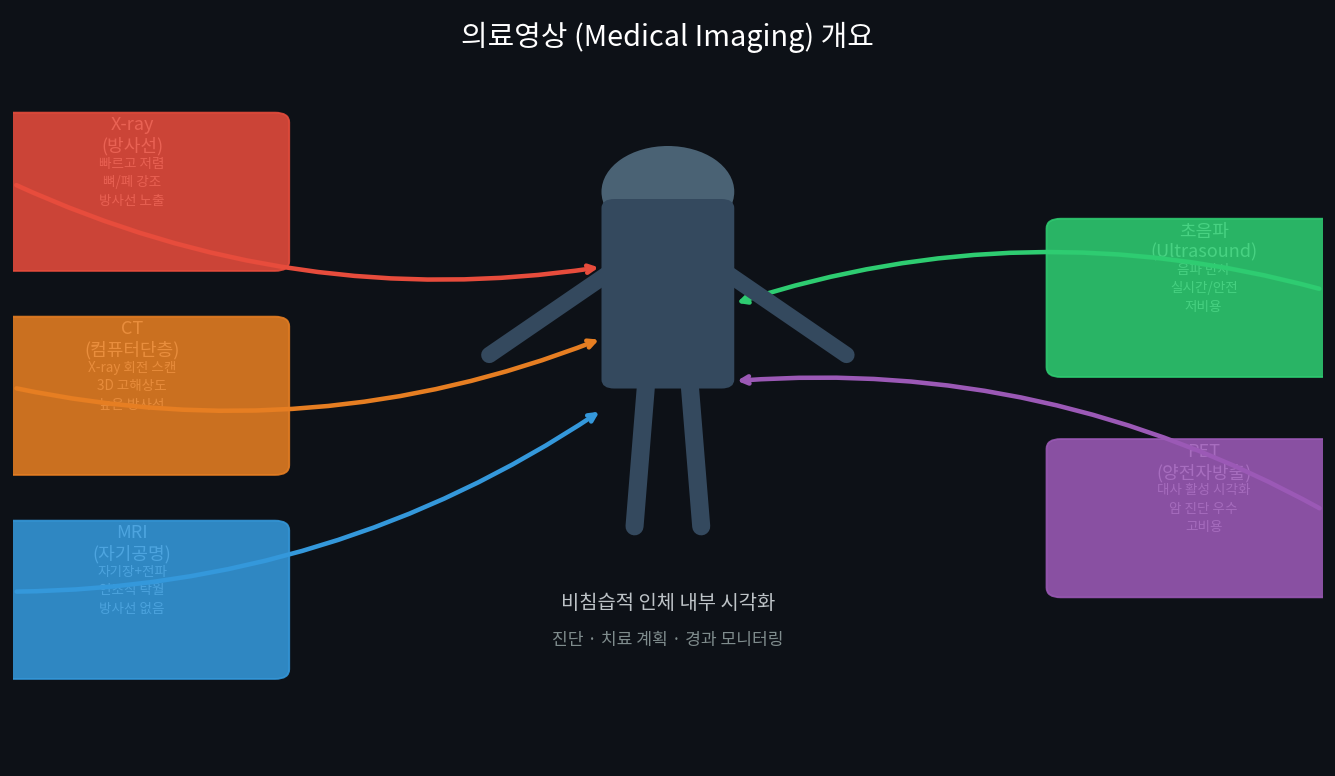

<sub><b>그림 1-1. 5대 의료영상 기법 개요 — 각 기법의 원리와 적용 영역</b></sub>

</div>

## 1.1 대표 의료영상 예시

아래 이미지는 **강의용 대표 의료영상 예시**입니다.  
실제 환자 데이터가 아니라 **설명용으로 생성한 예시 이미지**이며, Colab에서도 바로 표시되도록 구성했습니다.


In [ ]:
# ─────────────────────────────────────────────────────
#  📊 추가 시각화: 대표 의료영상 예시 모음 (Colab 친화형)
# ─────────────────────────────────────────────────────

def representative_medical_images(size=224, seed=7):
    np.random.seed(seed)
    y, x = np.mgrid[0:size, 0:size]
    cx, cy = size//2, size//2

    # 1) Chest X-ray
    xray = np.zeros((size, size), dtype=np.float32) + 0.15
    thorax = (((y-cy)/1.25)**2 + ((x-cx)/1.0)**2) < (size*0.34)**2
    xray[thorax] = 0.35
    left_lung  = (((y-(cy+8))/1.45)**2 + ((x-(cx-40))/1.0)**2) < (size*0.17)**2
    right_lung = (((y-(cy+8))/1.45)**2 + ((x-(cx+40))/1.0)**2) < (size*0.17)**2
    xray[left_lung | right_lung] = 0.07
    xray[:, cx-5:cx+5] = 0.75
    heart = (((y-(cy+18))/1.2)**2 + ((x-(cx+8))/0.9)**2) < (size*0.11)**2
    xray[heart] = 0.58
    rib_ring = ((((y-cy)/1.25)**2 + ((x-cx)/1.0)**2) > (size*0.30)**2) & thorax
    xray[rib_ring] = 0.9
    xray = np.clip(xray + np.random.normal(0, 0.02, xray.shape), 0, 1)

    # 2) Brain MRI
    mri = np.zeros((size, size), dtype=np.float32) + 0.05
    brain = ((y-cy)**2/(size*0.34)**2 + (x-cx)**2/(size*0.30)**2) < 1
    mri[brain] = 0.45
    wm = ((y-cy)**2/(size*0.22)**2 + (x-cx)**2/(size*0.20)**2) < 1
    mri[wm] = 0.70
    vent = ((y-cy)**2/(size*0.08)**2 + (x-cx)**2/(size*0.04)**2) < 1
    mri[vent] = 0.18
    cortical_ring = brain & (~wm)
    mri[cortical_ring] += 0.08*np.sin((x[cortical_ring]-cx)/8)
    mri = np.clip(mri + np.random.normal(0, 0.015, mri.shape), 0, 1)

    # 3) Abdomen CT
    ct = np.zeros((size, size), dtype=np.float32) + 0.05
    body = ((y-cy)**2/(size*0.36)**2 + (x-cx)**2/(size*0.30)**2) < 1
    ct[body] = 0.30
    liver = ((y-(cy-10))**2/(size*0.14)**2 + (x-(cx+32))**2/(size*0.18)**2) < 1
    spleen = ((y-(cy-8))**2/(size*0.11)**2 + (x-(cx-38))**2/(size*0.10)**2) < 1
    spine = ((y-(cy+42))**2/(size*0.07)**2 + (x-cx)**2/(size*0.06)**2) < 1
    ct[liver] = 0.52
    ct[spleen] = 0.46
    ct[spine] = 0.85
    ct = np.clip(ct + np.random.normal(0, 0.018, ct.shape), 0, 1)

    # 4) Ultrasound
    us = np.zeros((size, size), dtype=np.float32)
    yy = y - 12
    xx = x - cx
    r = np.sqrt(yy**2 + xx**2)
    ang = np.arctan2(xx, yy + 1e-6)
    sector = (r < size*0.90) & (np.abs(ang) < 0.85) & (yy > 0)
    us[sector] = 0.18 + 0.45*np.exp(-r[sector]/85)
    us[sector] += 0.10*np.random.rand(sector.sum())
    for rr in [60, 95, 130]:
        arc = np.abs(r - rr) < 2.5
        us[sector & arc] = 0.85
    us = np.clip(us, 0, 1)

    # 5) Histopathology (H&E-like)
    he = np.ones((size, size, 3), dtype=np.float32)
    he[..., 0] = 0.95
    he[..., 1] = 0.78
    he[..., 2] = 0.88
    for _ in range(180):
        px, py = np.random.randint(0, size, 2)
        rx, ry = np.random.randint(4, 9), np.random.randint(4, 9)
        mask = (((x-px)/rx)**2 + ((y-py)/ry)**2) < 1
        he[mask] = [0.45 + 0.15*np.random.rand(), 0.25, 0.65 + 0.15*np.random.rand()]
    he = np.clip(he, 0, 1)

    # 6) Segmentation example
    seg_base = np.dstack([xray, xray, xray])
    lung_mask = left_lung | right_lung
    seg = seg_base.copy()
    seg[..., 1] = np.where(lung_mask, 0.85, seg[..., 1])
    seg[..., 0] = np.where(lung_mask, 0.90, seg[..., 0] * 0.7)

    return xray, mri, ct, us, he, seg

xray_rep, mri_rep, ct_rep, us_rep, he_rep, seg_rep = representative_medical_images()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('대표 의료영상 예시', fontsize=15, fontweight='bold')

items = [
    (xray_rep, 'bone', 'Chest X-ray 예시'),
    (mri_rep, 'magma', 'Brain MRI 예시'),
    (ct_rep, 'gray', 'Abdomen CT 예시'),
    (us_rep, 'gray', 'Ultrasound 예시'),
    (he_rep, None, '병리조직(H&E) 예시'),
    (seg_rep, None, '분할 결과 예시'),
]

for ax, (img, cmap, title) in zip(axes.flat, items):
    if cmap is None:
        ax.imshow(img)
    else:
        ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()
print('✅ 대표 의료영상 예시를 추가했습니다.')


In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 1: 주요 의료영상 기법 비교 인포그래픽
# ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.suptitle('주요 의료영상 기법 시뮬레이션', fontsize=16, fontweight='bold', y=1.02)

# ① X-ray 시뮬레이션 — 뼈 구조 강조
xray = np.zeros((200, 200))
# 흉곽 윤곽
for r in range(200):
    for c in range(200):
        dist_outer = np.sqrt((r-100)**2/1.5 + (c-100)**2)
        dist_inner = np.sqrt((r-100)**2/1.4 + (c-100)**2)
        if 65 < dist_outer < 80:
            xray[r, c] = 0.9
        elif 50 < dist_inner < 60:
            xray[r, c] = 0.7
        elif dist_inner < 50:
            xray[r, c] = 0.15
# 척추
xray[60:160, 95:105] = 0.95
for i in range(6):
    xray[60+i*18:72+i*18, 90:110] = 1.0
xray += np.random.normal(0, 0.03, xray.shape)
axes[0].imshow(xray, cmap='bone', vmin=0, vmax=1)
axes[0].set_title('X-ray (방사선)\n뼈·폐 구조 강조', fontsize=10, fontweight='bold')
axes[0].axis('off')
axes[0].text(100, 195, '원리: 전자기 방사선 투과', ha='center', fontsize=7, color='gray')

# ② CT 시뮬레이션 — 3D 단면 느낌
ct = np.zeros((200, 200))
for r in range(200):
    for c in range(200):
        d = np.sqrt((r-100)**2 + (c-100)**2)
        if d < 80:
            ct[r, c] = 0.2 + 0.6*(1 - d/80)
        if d < 80:
            # 폐 (어두운 영역)
            for lx, ly in [(70,75), (130,75)]:
                ld = np.sqrt((r-ly)**2 + (c-lx)**2)
                if ld < 30:
                    ct[r, c] = 0.05
            # 심장 (밝은 영역)
            hd = np.sqrt((r-90)**2 + (c-105)**2)
            if hd < 22:
                ct[r, c] = 0.75
# 뼈 (외곽 밝게)
for r in range(200):
    for c in range(200):
        d = np.sqrt((r-100)**2 + (c-100)**2)
        if 75 < d < 82:
            ct[r, c] = 1.0
ct += np.random.normal(0, 0.02, ct.shape)
ct = np.clip(ct, 0, 1)
axes[1].imshow(ct, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('CT (컴퓨터단층촬영)\n3D 단면 고해상도', fontsize=10, fontweight='bold')
axes[1].axis('off')
axes[1].text(100, 195, '원리: X-ray 회전 스캔', ha='center', fontsize=7, color='gray')

# ③ MRI 시뮬레이션 — 연조직 강조
mri = np.zeros((200, 200))
for r in range(200):
    for c in range(200):
        d = np.sqrt((r-100)**2 + (c-100)**2)
        if d < 85:
            mri[r, c] = 0.4 + 0.5*np.sin(d/15)
            # 회백질 구조
            if 40 < d < 55:
                mri[r, c] = 0.85
            elif d < 40:
                mri[r, c] = 0.6 + 0.3*np.cos(r/20)*np.cos(c/20)
mri += np.random.normal(0, 0.02, mri.shape)
mri = np.clip(mri, 0, 1)
axes[2].imshow(mri, cmap='magma', vmin=0, vmax=1)
axes[2].set_title('MRI (자기공명영상)\n연조직 분석 우수', fontsize=10, fontweight='bold')
axes[2].axis('off')
axes[2].text(100, 195, '원리: 자기장 + 전파 사용', ha='center', fontsize=7, color='gray')

# ④ 초음파 시뮬레이션
us = np.zeros((200, 200))
# 부채꼴 스캔 패턴
for r in range(200):
    for c in range(200):
        d = np.sqrt((r-10)**2 + (c-100)**2)
        angle = np.arctan2(c-100, r-10)
        if d < 190 and -0.8 < angle < 0.8:
            us[r, c] = 0.15 + 0.6*np.exp(-d/80) + 0.15*np.random.rand()
            if 60 < d < 65 or 100 < d < 105 or 140 < d < 145:
                us[r, c] = 0.85
us = np.clip(us, 0, 1)
axes[3].imshow(us, cmap='gray', vmin=0, vmax=1)
axes[3].set_title('초음파 (Ultrasound)\n실시간 · 안전', fontsize=10, fontweight='bold')
axes[3].axis('off')
axes[3].text(100, 195, '원리: 음파 반사', ha='center', fontsize=7, color='gray')

# ⑤ PET 시뮬레이션 — 대사 활성도 (컬러)
pet = np.zeros((200, 200))
# 뇌 활성 영역
regions = [(100, 100, 70, 1.0), (70, 80, 20, 0.9), (130, 80, 20, 0.85),
           (100, 130, 15, 0.7), (60, 120, 18, 0.6), (140, 115, 18, 0.65)]
for cx, cy, rad, val in regions:
    for r in range(200):
        for c in range(200):
            d = np.sqrt((r-cy)**2 + (c-cx)**2)
            if d < rad:
                pet[r, c] = max(pet[r, c], val*(1 - d/rad*0.4))
pet += np.random.normal(0, 0.02, pet.shape)
pet = np.clip(pet, 0, 1)
axes[4].imshow(pet, cmap='hot', vmin=0, vmax=1)
axes[4].set_title('PET (양전자방출)\n대사 활성도 시각화', fontsize=10, fontweight='bold')
axes[4].axis('off')
axes[4].text(100, 195, '원리: 방사성 동위원소', ha='center', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig('fig1_modalities.png', bbox_inches='tight', dpi=120)
plt.show()
print('\n📌 각 기법의 특징을 시각적으로 확인하세요!')

## 1.2 주요 의료영상 기법 비교표

| 기법 | 원리 | 장점 | 단점 | 주요 용도 |
|------|------|------|------|-----------|
| **X-ray** | 전자기 방사선 투과 | 빠름·저렴·뼈 우수 | 중첩 구조·방사선 노출 | 폐렴, 골절 |
| **CT** | X-ray 회전 스캔 | 3D·고해상도 | 높은 방사선·비용 | 암·출혈 진단 |
| **MRI** | 자기장 + 전파 | 연조직 탁월·방사선 無 | 긴 검사시간·고비용 | 뇌·척수·관절 |
| **초음파** | 음파 반사 | 실시간·안전·저비용 | 공기·뼈 영향·주관적 | 태아·심장 |
| **PET** | 방사성 동위원소 | 대사 정보·암 진단 | 매우 고비용·방사선 | 암·신경계 |

## 1.3 의료영상 처리 파이프라인

```
  📡 영상 획득          🔧 전처리              🔍 분할
  (Acquisition)  →→→  (Preprocessing)  →→→  (Segmentation)
      ↓                    ↓                     ↓
  기기에서              노이즈 제거            관심 영역
  원본 데이터          정규화·강화             (ROI) 추출
      ↓                    ↓                     ↓
  🧬 특성 추출          🤖 AI 분류/진단
  (Feature Extraction) → (Classification)
```

<div align="center">

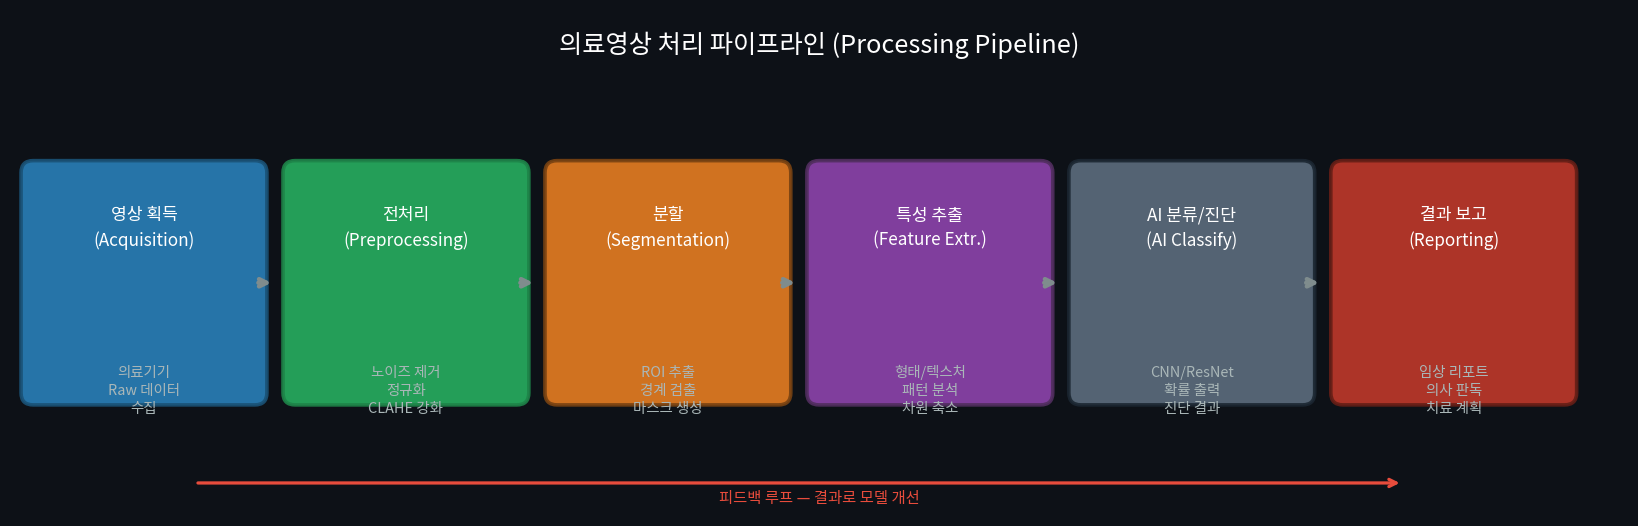

<sub><b>그림 1-2. 의료영상 처리 파이프라인 6단계</b></sub>

</div>

In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 2: 영상 처리 파이프라인 단계별 시연
# ─────────────────────────────────────────────────────

np.random.seed(42)

def make_synthetic_xray(size=256):
    """흉부 X-ray 유사 합성 이미지 생성"""
    img = np.zeros((size, size), dtype=np.float32)
    cx, cy = size//2, size//2
    # 흉곽
    for r in range(size):
        for c in range(size):
            d = np.sqrt(((r-cy)/1.3)**2 + ((c-cx))**2)
            if 90 < d < 105:
                img[r, c] = 0.85
            elif d < 90:
                img[r, c] = 0.25
    # 폐
    for lx, lsign in [(cx-38, 1), (cx+38, -1)]:
        for r in range(size):
            for c in range(size):
                d = np.sqrt(((r-cy+10)/1.3)**2 + (c-lx)**2)
                if d < 42:
                    img[r, c] = 0.1 + 0.05*np.random.rand()
    # 심장
    for r in range(size):
        for c in range(size):
            d = np.sqrt(((r-cy+5)/1.1)**2 + ((c-cx+10)/0.85)**2)
            if d < 28:
                img[r, c] = 0.65
    # 척추
    img[cy-70:cy+70, cx-8:cx+8] = 0.9
    # 노이즈
    img += np.random.normal(0, 0.04, img.shape)
    return np.clip(img, 0, 1)

original = make_synthetic_xray(256)

# 전처리 단계
img_uint8 = (original * 255).astype(np.uint8)

# 1) 노이즈 제거 (Gaussian Blur)
denoised = cv2.GaussianBlur(img_uint8, (5, 5), 0)

# 2) CLAHE — 의료영상 표준 명암 강화
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(denoised)

# 3) 엣지 검출 (Canny)
edges = cv2.Canny(enhanced, 40, 120)

# 4) 이진화 (Otsu)
_, binary_otsu = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5) 적응형 분할
adaptive = cv2.adaptiveThreshold(enhanced, 255,
                                  cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 31, 5)

# 시각화
titles = ['① 원본 (합성 X-ray)', '② 노이즈 제거\n(Gaussian Blur)',
          '③ 명암 강화\n(CLAHE)', '④ 엣지 검출\n(Canny)',
          '⑤ Otsu 이진화', '⑥ 적응형 분할']
images = [original, denoised/255, enhanced/255, edges/255, binary_otsu/255, adaptive/255]
cmaps  = ['bone']*3 + ['hot', 'gray', 'gray']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('영상 처리 파이프라인 단계별 결과', fontsize=14, fontweight='bold')

for ax, img, title, cmap in zip(axes.flat, images, titles, cmaps):
    ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('fig2_pipeline.png', bbox_inches='tight')
plt.show()
print('\n💡 TIP: CLAHE는 의료영상에서 히스토그램 균등화보다 더 자주 쓰입니다!')

---
# 🧠 Part 2: 의료인공지능 이론

## 2.1 딥러닝(Deep Learning) 기초

딥러닝은 **다층 신경망**을 이용해 데이터에서 자동으로 특징을 학습합니다.

### 핵심 용어 정리

| 용어 | 설명 | 의료영상 적용 |
|------|------|---------------|
| **뉴런 (Neuron)** | 입력 신호를 받아 출력하는 계산 단위 | 픽셀값 처리 |
| **가중치 (Weight)** | 각 연결의 중요도 | 종양 특징 강조 |
| **활성화함수 (Activation)** | 비선형 변환 (ReLU, Sigmoid 등) | 복잡한 패턴 학습 |
| **손실함수 (Loss)** | 예측 오차 측정 | 진단 정확도 최적화 |
| **역전파 (Backprop)** | 오차를 역방향으로 전달 | 모델 자동 학습 |

<div align="center">

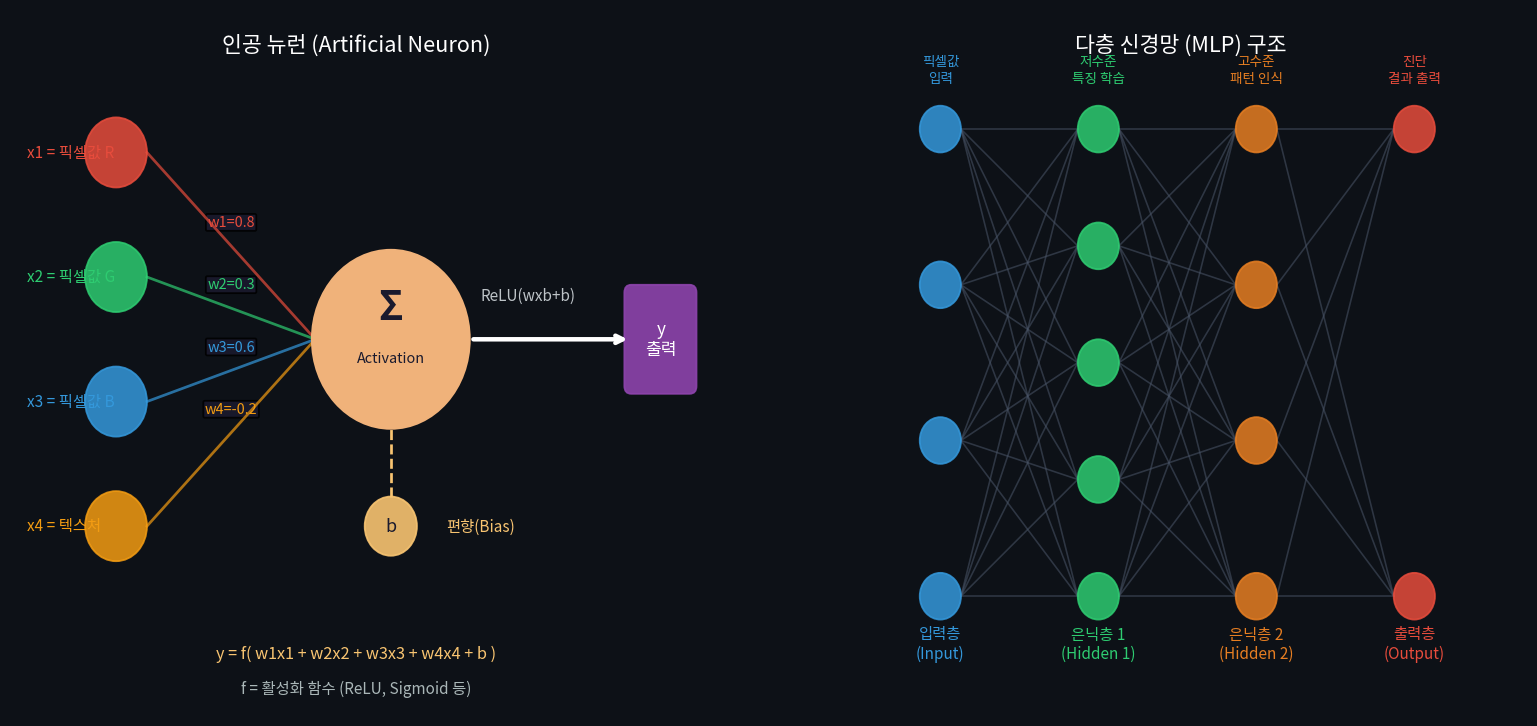

<sub><b>그림 2-1. 인공 뉴런(Artificial Neuron) 구조와 다층 신경망(MLP)</b></sub>

</div>

In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 3: 주요 활성화함수 비교
# ─────────────────────────────────────────────────────

x = np.linspace(-4, 4, 300)

def relu(x):    return np.maximum(0, x)
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x):    return np.tanh(x)
def leaky_relu(x, alpha=0.1): return np.where(x > 0, x, alpha*x)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('딥러닝 핵심: 활성화함수 (Activation Functions)', fontsize=14, fontweight='bold')

funcs = [relu, sigmoid, tanh, leaky_relu]
names = ['ReLU\n(가장 많이 사용)', 'Sigmoid\n(이진 분류 출력)',
         'Tanh\n(중심화된 출력)', 'Leaky ReLU\n(음수 기울기 유지)']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
formulas = ['f(x) = max(0, x)', 'f(x) = 1/(1+e⁻ˣ)', 'f(x) = tanh(x)', 'f(x) = max(αx, x)']

for ax, fn, name, color, formula in zip(axes, funcs, names, colors, formulas):
    y = fn(x)
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('입력 x', fontsize=9)
    ax.set_ylabel('출력 f(x)', fontsize=9)
    ax.text(0.05, 0.95, formula, transform=ax.transAxes,
            fontsize=9, va='top', color=color,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-4, 4)

plt.tight_layout()
plt.savefig('fig3_activations.png', bbox_inches='tight')
plt.show()

## 2.2 의료영상 AI의 주요 작업 4가지

```
┌──────────────┬────────────────────────────────┬──────────────────────────┐
│   작업 유형   │         설명                   │     의료영상 예시         │
├──────────────┼────────────────────────────────┼──────────────────────────┤
│ 분류         │ 이미지 전체에 레이블 부여       │ 폐렴 여부 판별            │
│ Classification│                               │ (정상 / 비정상)           │
├──────────────┼────────────────────────────────┼──────────────────────────┤
│ 탐지         │ 병변 위치 + 경계 박스           │ 결절 위치 탐지             │
│ Detection    │                               │ (x, y, w, h)              │
├──────────────┼────────────────────────────────┼──────────────────────────┤
│ 분할         │ 픽셀 단위 레이블 부여           │ 종양 경계 추출             │
│ Segmentation │                               │ (마스크 이미지)            │
├──────────────┼────────────────────────────────┼──────────────────────────┤
│ 회귀         │ 연속값 예측                    │ 종양 크기(cm) 측정         │
│ Regression   │                               │ 나이 예측                  │
└──────────────┴────────────────────────────────┴──────────────────────────┘
```

In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 4: AI 작업 유형 시각 비교
# ─────────────────────────────────────────────────────

def make_lesion_image(size=200, seed=7):
    np.random.seed(seed)
    img = np.ones((size, size)) * 0.3
    # 배경 조직 텍스처
    for _ in range(300):
        r, c = np.random.randint(0, size, 2)
        img[r, c] += np.random.rand() * 0.2
    img = cv2.GaussianBlur(img, (15, 15), 0)
    # 병변 추가
    lesion_pos = [(80, 100, 22), (130, 70, 14)]
    for ly, lx, lr in lesion_pos:
        for r in range(size):
            for c in range(size):
                d = np.sqrt((r-ly)**2 + (c-lx)**2)
                if d < lr:
                    img[r, c] = 0.85 - 0.3*(d/lr)
    img = np.clip(img + np.random.normal(0, 0.02, img.shape), 0, 1)
    return img, lesion_pos

img_base, lesions = make_lesion_image()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('의료영상 AI 작업 유형 (합성 병변 이미지)', fontsize=13, fontweight='bold')

# ① 분류
axes[0].imshow(img_base, cmap='gray')
axes[0].set_title('① 분류 (Classification)\n"비정상 (병변 있음) ✓"', fontsize=10)
axes[0].axis('off')
axes[0].text(100, 190, 'Output: 비정상 (98.3%)', ha='center', fontsize=9,
             color='red', bbox=dict(boxstyle='round', fc='yellow', alpha=0.8))

# ② 탐지
axes[1].imshow(img_base, cmap='gray')
for ly, lx, lr in lesions:
    rect = patches.Rectangle((lx-lr-5, ly-lr-5), (lr+5)*2, (lr+5)*2,
                               linewidth=2.5, edgecolor='lime', facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(lx, ly-lr-8, f'병변 ({int(lr*0.4)}mm)', fontsize=8,
                 color='lime', ha='center')
axes[1].set_title('② 탐지 (Detection)\n병변 위치 + 경계박스', fontsize=10)
axes[1].axis('off')

# ③ 분할
mask = np.zeros_like(img_base)
for ly, lx, lr in lesions:
    for r in range(200):
        for c in range(200):
            if np.sqrt((r-ly)**2 + (c-lx)**2) < lr:
                mask[r, c] = 1
overlay = np.stack([img_base, img_base, img_base], axis=-1)
overlay[:,:,0] = np.where(mask > 0, 1.0, img_base)  # 빨간색 마스크
overlay[:,:,1] = np.where(mask > 0, 0.2, img_base)
overlay[:,:,2] = np.where(mask > 0, 0.2, img_base)
axes[2].imshow(overlay)
axes[2].set_title('③ 분할 (Segmentation)\n픽셀 단위 병변 경계', fontsize=10)
axes[2].axis('off')

# ④ 회귀 (크기 예측)
axes[3].imshow(img_base, cmap='gray')
for i, (ly, lx, lr) in enumerate(lesions):
    circle = plt.Circle((lx, ly), lr, color='cyan', fill=False, linewidth=2)
    axes[3].add_patch(circle)
    size_mm = lr * 0.4
    axes[3].annotate('', xy=(lx+lr, ly), xytext=(lx-lr, ly),
                     arrowprops=dict(arrowstyle='<->', color='cyan', lw=1.5))
    axes[3].text(lx, ly+lr+8, f'{size_mm:.1f}mm', ha='center', fontsize=9, color='cyan')
axes[3].set_title('④ 회귀 (Regression)\n종양 크기(mm) 정량 예측', fontsize=10)
axes[3].axis('off')

plt.tight_layout()
plt.savefig('fig4_tasks.png', bbox_inches='tight')
plt.show()

## 2.3 CNN 아키텍처 — 의료영상 AI의 핵심

**CNN (Convolutional Neural Network)** 은 이미지 분석에 특화된 신경망입니다.

```
입력 이미지                                                    출력
 [256×256]  →  [Conv] → [ReLU] → [Pool]  →  [Conv] → [ReLU] → [Pool]  →  [FC] → 진단 결과
                ↓                                 ↓                          ↓
            특징 맵 생성                       고수준 특징                  확률 분포
            (엣지, 텍스처)                    (모양, 패턴)                 (0.95 = 암)
```

### 유명한 CNN 아키텍처

| 모델 | 연도 | 특징 | 의료영상 활용 |
|------|------|------|---------------|
| **AlexNet** | 2012 | CNN 붐의 시작 | 기초 분류 |
| **VGG** | 2014 | 깊고 단순한 구조 | 전이학습 |
| **ResNet** | 2015 | 잔차 연결(skip) | 심층 분류 |
| **DenseNet** | 2017 | 모든 레이어 연결 | 영상 분류 |
| **U-Net** | 2015 | 인코더-디코더 | **분할 (표준)** |

<div align="center">

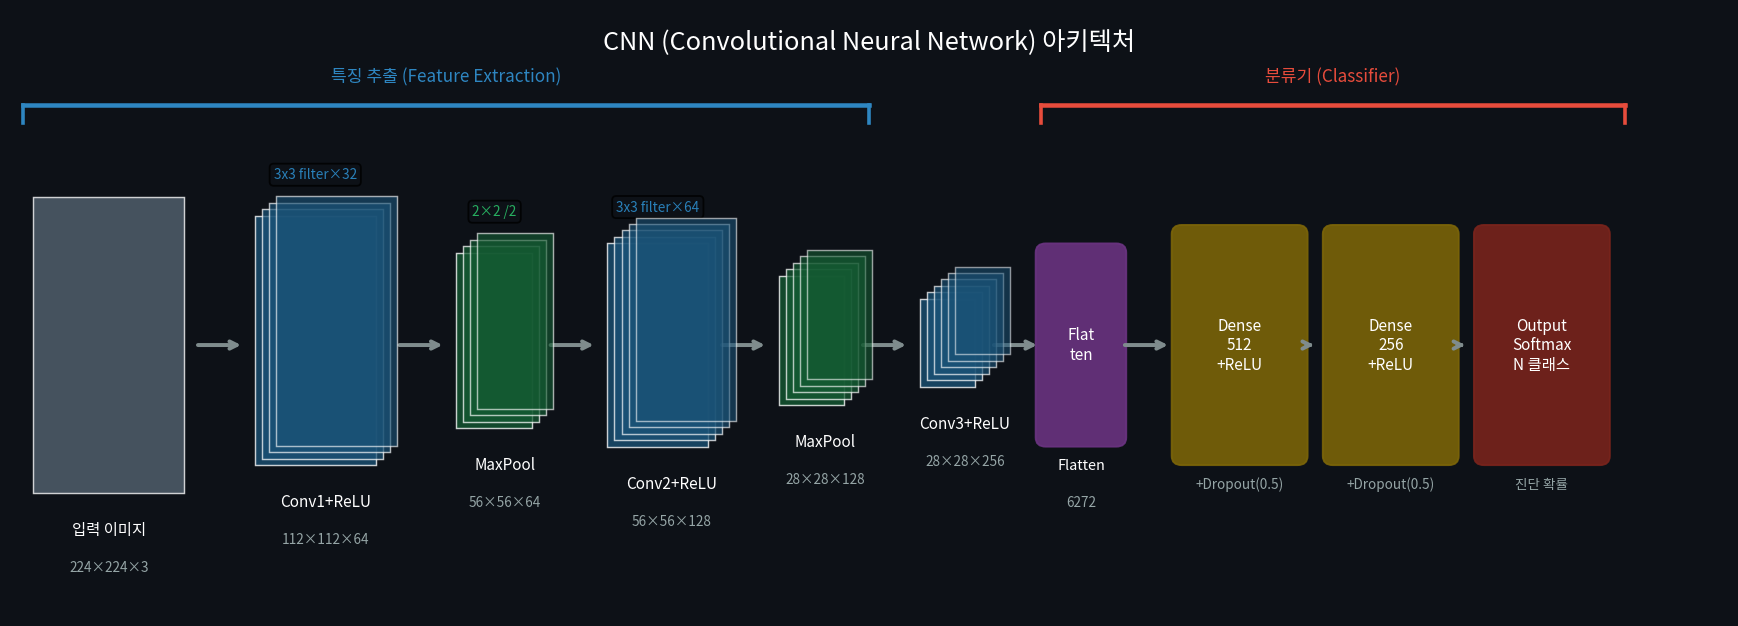

<sub><b>그림 2-2. CNN 아키텍처 전체 구조 — 특징 추출기 + 분류기</b></sub>

</div>

<div align="center">

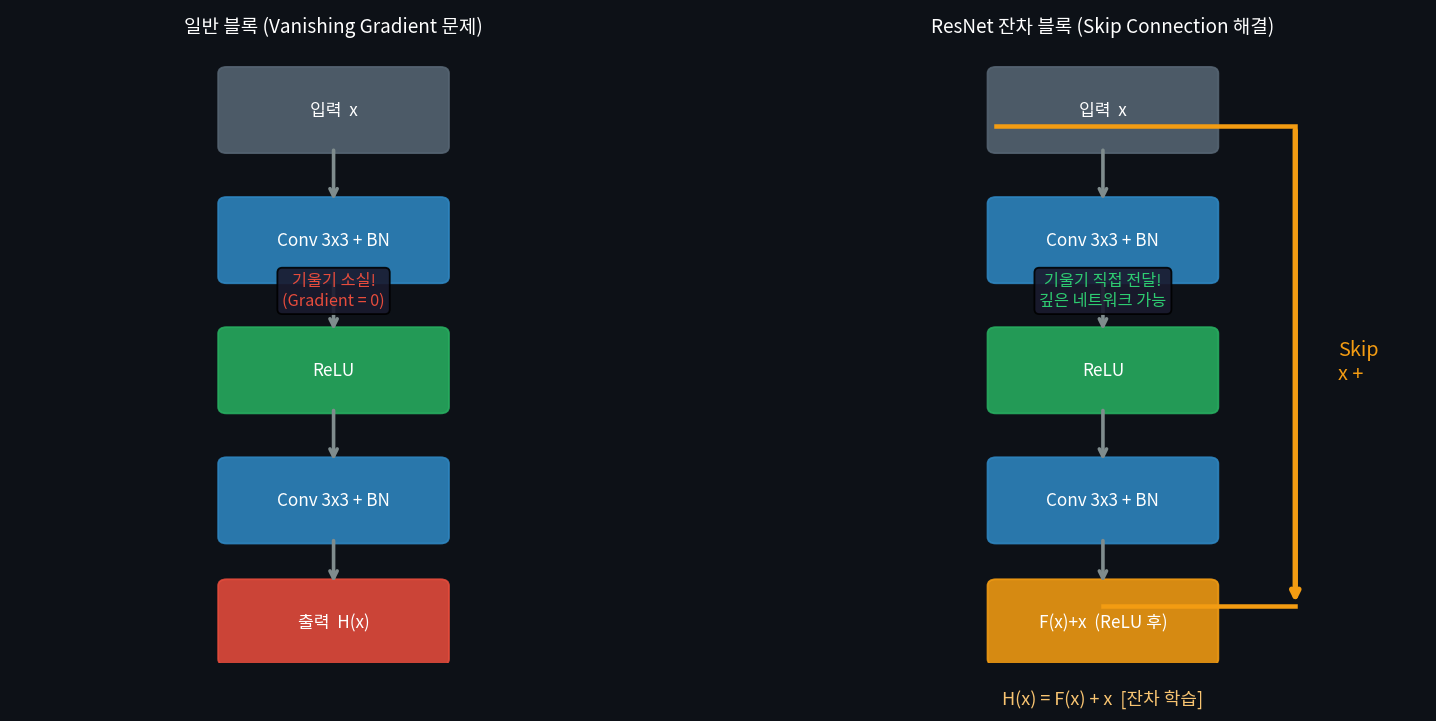

<sub><b>그림 2-3. ResNet 잔차 블록(Residual Block) — Skip Connection으로 기울기 소실 해결</b></sub>

</div>

In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 5: CNN 합성곱 연산 직관적 이해
# ─────────────────────────────────────────────────────

np.random.seed(0)
patch_size = 8
img_small = np.random.rand(8, 8) * 0.5 + 0.2
img_small[2:5, 2:5] = 0.9  # 밝은 패턴 ("병변")

# 필터들
filters = {
    '수평 엣지 검출': np.array([[-1,-1,-1],[0,0,0],[1,1,1]]),
    '수직 엣지 검출': np.array([[-1,0,1],[-1,0,1],[-1,0,1]]),
    '밝은 영역 탐지': np.ones((3,3))/9,
    '샤프닝': np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
}

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('CNN 합성곱(Convolution) 연산 — 필터가 이미지에서 특징을 추출한다',
             fontsize=13, fontweight='bold')

# 원본 이미지
for row in range(2):
    axes[row, 0].imshow(img_small, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title('원본\n입력 이미지', fontsize=10, fontweight='bold')
    axes[row, 0].axis('off')

for col, (fname, filt) in enumerate(filters.items(), start=1):
    row = (col - 1) // 2
    # 필터 시각화
    axes[row, col if col < 3 else col-2+2].imshow(
        filt, cmap='RdBu', vmin=-2, vmax=2)

# 다시 깔끔하게
plt.close()

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('CNN 합성곱(Convolution) 연산 — 필터가 이미지에서 특징을 추출한다',
             fontsize=13, fontweight='bold')

positions = [(0,0),(0,1),(0,2),(1,1),(1,2)]
titles_all = ['원본 이미지', '수평 엣지 필터', '수평 엣지 결과',
              '수직 엣지 필터', '수직 엣지 결과']

img_f32 = img_small.astype(np.float32)
h_filter = np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=np.float32)
v_filter = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32)
h_result = cv2.filter2D(img_f32, -1, h_filter)
v_result = cv2.filter2D(img_f32, -1, v_filter)

items = [
    (img_small, 'gray', '원본 이미지', ''),
    (h_filter,  'RdBu', '수평 엣지 필터\n(Horizontal Edge)', '-1:파랑, +1:빨강'),
    (h_result,  'hot',  '수평 엣지 특징맵\n(Feature Map)', '밝을수록 강한 수평 엣지'),
    (v_filter,  'RdBu', '수직 엣지 필터\n(Vertical Edge)', '-1:파랑, +1:빨강'),
    (v_result,  'hot',  '수직 엣지 특징맵', '밝을수록 강한 수직 엣지'),
]

for ax, (img_d, cmap, title, note) in zip([axes[0,0],axes[0,1],axes[0,2],axes[1,1],axes[1,2]], items):
    ax.imshow(img_d, cmap=cmap)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')
    if note:
        ax.text(0.5, -0.08, note, transform=ax.transAxes,
                ha='center', fontsize=7.5, color='dimgray')

# 풀링 설명
pool_in  = np.array([[3,5,2,1],[4,6,3,2],[1,2,8,5],[0,1,3,4]], dtype=float)
pool_out = np.array([[6,3],[2,8]], dtype=float)  # max pooling 결과

axes[0,3].imshow(pool_in, cmap='YlOrRd', vmin=0, vmax=9)
for r in range(4):
    for c in range(4):
        axes[0,3].text(c, r, int(pool_in[r,c]), ha='center', va='center', fontsize=12, fontweight='bold')
axes[0,3].set_title('Max Pooling\n입력 (4×4)', fontsize=9, fontweight='bold')
axes[0,3].axis('off')

axes[1,3].imshow(pool_out, cmap='YlOrRd', vmin=0, vmax=9)
for r in range(2):
    for c in range(2):
        axes[1,3].text(c, r, int(pool_out[r,c]), ha='center', va='center', fontsize=16, fontweight='bold')
axes[1,3].set_title('Max Pooling\n출력 (2×2) — 크기 절반', fontsize=9, fontweight='bold')
axes[1,3].axis('off')

# CNN 구조 요약
axes[0,4].axis('off')
axes[1,4].axis('off')
summary = (
    'CNN 주요 레이어 요약\n'
    '━━━━━━━━━━━━━━━━━━\n'
    '🔲 Conv Layer\n'
    '   → 필터로 특징 추출\n\n'
    '⚡ ReLU\n'
    '   → 비선형 변환\n\n'
    '🔽 Pooling\n'
    '   → 크기 축소\n\n'
    '📊 FC Layer\n'
    '   → 최종 분류\n'
)
axes[0,4].text(0.1, 0.95, summary, transform=axes[0,4].transAxes,
               va='top', fontsize=9.5,
               bbox=dict(boxstyle='round', facecolor='#eaf4fb', alpha=0.9))

plt.tight_layout()
plt.savefig('fig5_cnn.png', bbox_inches='tight')
plt.show()

---
# 💻 Part 3: 실습 예제

## 3.1 NumPy & OpenCV 기초 영상 처리

In [ ]:
# ─────────────────────────────────────────────────────
#  🧪 실습 1: NumPy 배열로 의료영상 다루기
# ─────────────────────────────────────────────────────

import numpy as np

print('=' * 50)
print('실습 1: 의료영상 = NumPy 배열')
print('=' * 50)

# 512×512 그레이스케일 이미지 (모의 CT 슬라이스)
np.random.seed(42)
image = np.random.rand(512, 512).astype(np.float32)

print(f'\n이미지 shape  : {image.shape}  ← (높이, 너비)')
print(f'데이터 타입   : {image.dtype}')
print(f'값 범위       : [{image.min():.4f}, {image.max():.4f}]')
print(f'평균 픽셀값   : {image.mean():.4f}')
print(f'표준편차      : {image.std():.4f}')

# ── 정규화 방법 비교 ──
norm_minmax = (image - image.min()) / (image.max() - image.min())  # [0, 1]
norm_zscore = (image - image.mean()) / image.std()                  # z-score
norm_uint8  = (norm_minmax * 255).astype(np.uint8)                  # [0, 255]

print('\n── 정규화 방법 비교 ──')
print(f'Min-Max [0,1]  : 범위 [{norm_minmax.min():.2f}, {norm_minmax.max():.2f}]')
print(f'Z-score        : 평균 {norm_zscore.mean():.4f}, 표준편차 {norm_zscore.std():.4f}')
print(f'8bit [0,255]   : 타입 {norm_uint8.dtype}')

print('\n💡 의료영상에서는 Min-Max 또는 Z-score 정규화를 가장 많이 사용합니다!')

In [ ]:
# ─────────────────────────────────────────────────────
#  🧪 실습 2: OpenCV 기초 필터링
# ─────────────────────────────────────────────────────

import cv2

# 모의 의료영상 생성 (노이즈 있는 CT 시뮬레이션)
np.random.seed(0)
size = 256
test_img = np.zeros((size, size), dtype=np.float32)

# 원형 구조 (장기 시뮬레이션)
cx, cy = size//2, size//2
for r in range(size):
    for c in range(size):
        d = np.sqrt((r-cy)**2 + (c-cx)**2)
        if d < 100:
            test_img[r, c] = 0.6 - 0.4*(d/100)
        if d < 35:
            test_img[r, c] = 0.9

# 가우시안 노이즈 추가 (실제 CT 노이즈 시뮬레이션)
noisy = test_img + np.random.normal(0, 0.1, test_img.shape)
noisy = np.clip(noisy, 0, 1)
noisy_uint8 = (noisy * 255).astype(np.uint8)

# 필터 적용
gaussian = cv2.GaussianBlur(noisy_uint8, (5, 5), 0)
median   = cv2.medianBlur(noisy_uint8, 5)
clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_result = clahe_obj.apply(gaussian)

# 엣지 검출
edges_canny = cv2.Canny(gaussian, 50, 150)

# Otsu 이진화
_, otsu = cv2.threshold(gaussian, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('실습 2: OpenCV 기초 영상 처리 필터 비교', fontsize=14, fontweight='bold')

data = [
    (noisy,          'gray', '원본 + 노이즈\n(Gaussian noise σ=0.1)'),
    (gaussian/255,   'gray', 'Gaussian 블러 (5×5)\n노이즈 제거'),
    (median/255,     'gray', 'Median 블러 (5×5)\n점 노이즈에 효과적'),
    (clahe_result/255, 'gray', 'CLAHE\n국소 명암 강화'),
    (edges_canny/255, 'hot', 'Canny 엣지 검출\n경계선 추출'),
    (otsu/255,       'gray', f'Otsu 이진화\n자동 임계값 선택'),
]

for ax, (img, cmap, title) in zip(axes.flat, data):
    ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('fig6_filters.png', bbox_inches='tight')
plt.show()
print('\n💡 의료영상에서는 Gaussian/Median 노이즈 제거 후 CLAHE로 명암을 강화합니다!')

## 3.2 머신러닝 기초 (scikit-learn)

In [ ]:
# ─────────────────────────────────────────────────────
#  🧪 실습 3: SVM으로 손글씨 숫자 분류 (의료영상 분류와 동일한 원리)
# ─────────────────────────────────────────────────────

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# 데이터 로드 (8×8 손글씨 숫자, 의료영상의 간소화 버전)
digits = load_digits()
X, y = digits.data, digits.target

print(f'데이터셋 크기: {X.shape}  ({X.shape[0]}개 샘플, {X.shape[1]}개 특징)')
print(f'레이블: {np.unique(y)}')

# 표준화 (Z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/테스트 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'학습 데이터: {X_train.shape[0]}개 / 테스트 데이터: {X_test.shape[0]}개')

# SVM 학습
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm.fit(X_train, y_train)

# 평가
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'\n🎯 SVM 정확도: {acc:.4f} ({acc*100:.2f}%)')
print('\n📊 분류 보고서:')
print(classification_report(y_test, y_pred))

In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 6: 혼동 행렬 + 샘플 이미지
# ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('SVM 분류 결과 분석 (의료영상 분류와 동일한 평가 방법)',
             fontsize=12, fontweight='bold')

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=digits.target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('혼동 행렬 (Confusion Matrix)\n대각선 = 정확한 예측', fontsize=11)

# 오분류 예시
wrong_idx = np.where(y_pred != y_test)[0][:8]
if len(wrong_idx) > 0:
    inner_grid = gridspec.GridSpecFromSubplotSpec(
        2, 4, subplot_spec=axes[1].get_subplotspec())
    axes[1].remove()
    fig.text(0.73, 0.93, '오분류 사례 (빨강=실제, 파랑=예측)',
             ha='center', fontsize=10, fontweight='bold')
    for i, idx in enumerate(wrong_idx):
        ax = fig.add_subplot(inner_grid[i//4, i%4])
        ax.imshow(X_test[idx].reshape(8,8), cmap='gray', vmin=-2, vmax=2)
        ax.set_title(f'실제:{y_test[idx]}\n예측:{y_pred[idx]}',
                     fontsize=9, color='crimson')
        ax.axis('off')

plt.tight_layout()
plt.savefig('fig7_confusion.png', bbox_inches='tight')
plt.show()
print('\n💡 혼동 행렬에서 행=실제 클래스, 열=예측 클래스입니다!')

## 3.3 딥러닝 — CNN 모델 구현 (TensorFlow/Keras)

In [ ]:
# ─────────────────────────────────────────────────────
#  🧪 실습 4: CNN으로 MNIST 분류 (의료영상 분류와 동일 구조)
# ─────────────────────────────────────────────────────

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, models
    from tensorflow.keras.datasets import mnist
    print(f'✅ TensorFlow {tf.__version__} 로드 성공!')
    TF_AVAILABLE = True
except ImportError:
    print('⚠️  TensorFlow가 설치되지 않았습니다.')
    print('   설치 방법: pip install tensorflow')
    TF_AVAILABLE = False

In [ ]:
if TF_AVAILABLE:
    # ── 데이터 준비 ──
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
    X_train = X_train.astype('float32') / 255.0
    X_test  = X_test.astype('float32')  / 255.0

    # CNN용 형태 변환 (채널 추가)
    X_train_cnn = X_train.reshape(-1, 28, 28, 1)
    X_test_cnn  = X_test.reshape(-1, 28, 28, 1)

    print(f'학습 데이터 shape: {X_train_cnn.shape}')
    print(f'테스트 데이터 shape: {X_test_cnn.shape}')

    # ── CNN 모델 정의 ──
    cnn_model = models.Sequential([
        # 1번째 합성곱 블록
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # 2번째 합성곱 블록
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # 3번째 합성곱 블록
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),

        # 완전연결 레이어
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')  # 10개 클래스
    ], name='Medical_CNN')

    cnn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print('\n🏗️  CNN 모델 구조:')
    cnn_model.summary()

    # ── 모델 학습 ──
    print('\n🚀 모델 학습 시작...')
    history = cnn_model.fit(
        X_train_cnn, y_train,
        batch_size=128,
        epochs=8,
        validation_split=0.1,
        verbose=1
    )

    # ── 평가 ──
    test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
    print(f'\n🎯 테스트 정확도: {test_acc:.4f} ({test_acc*100:.2f}%)')

else:
    print('TensorFlow 없이 실행하려면 위 셀에서 TF 설치 후 재시작하세요.')

In [ ]:
if TF_AVAILABLE and 'history' in dir():
    # ── 학습 곡선 시각화 ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('CNN 학습 곡선 (Training Curves)', fontsize=13, fontweight='bold')

    # 손실
    axes[0].plot(history.history['loss'],     'b-o', label='학습 손실 (Train Loss)', lw=2)
    axes[0].plot(history.history['val_loss'], 'r-s', label='검증 손실 (Val Loss)',  lw=2)
    axes[0].set_xlabel('에포크 (Epoch)', fontsize=11)
    axes[0].set_ylabel('손실 (Loss)',    fontsize=11)
    axes[0].set_title('손실 곡선\n학습/검증 갭 = 과적합(Overfitting) 지표', fontsize=10)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.4)

    # 정확도
    axes[1].plot(history.history['accuracy'],     'b-o', label='학습 정확도', lw=2)
    axes[1].plot(history.history['val_accuracy'], 'r-s', label='검증 정확도', lw=2)
    axes[1].set_xlabel('에포크 (Epoch)', fontsize=11)
    axes[1].set_ylabel('정확도 (Accuracy)', fontsize=11)
    axes[1].set_title('정확도 곡선\n두 선이 수렴하면 잘 학습된 것', fontsize=10)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.4)
    axes[1].set_ylim([0.9, 1.0])

    plt.tight_layout()
    plt.savefig('fig8_training.png', bbox_inches='tight')
    plt.show()

    # 예측 샘플 시각화
    predictions = cnn_model.predict(X_test_cnn[:10], verbose=0)
    fig2, axes2 = plt.subplots(2, 5, figsize=(15, 6))
    fig2.suptitle('예측 결과 샘플 (파랑=정답, 빨강=오답)', fontsize=12, fontweight='bold')
    for i, ax in enumerate(axes2.flat):
        ax.imshow(X_test[i], cmap='gray')
        pred_label = np.argmax(predictions[i])
        conf = np.max(predictions[i])
        color = 'blue' if pred_label == y_test[i] else 'red'
        ax.set_title(f'예측: {pred_label}\n확신도: {conf:.2f}', fontsize=9, color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('fig9_predictions.png', bbox_inches='tight')
    plt.show()

## 3.4 성능 평가 지표 — 의료영상 AI에서 중요한 이유

<div align="center">

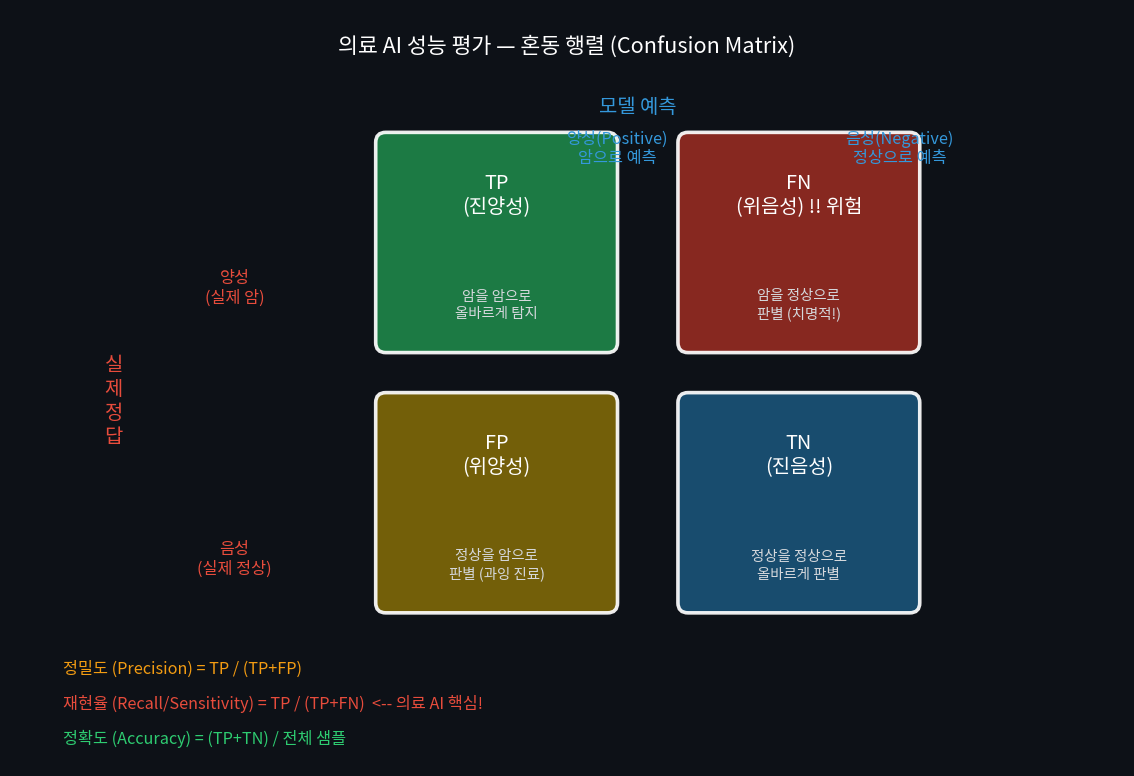

<sub><b>그림 3-1. 혼동 행렬(Confusion Matrix) 해석 — 의료 AI 성능 평가</b></sub>

</div>

In [ ]:
# ─────────────────────────────────────────────────────
#  🧪 실습 5: 의료 AI 성능 평가 지표 완전 분석
# ─────────────────────────────────────────────────────

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve
)

# 의료 시나리오: 암 진단 (1=암, 0=정상)
np.random.seed(42)
n_samples = 200

# 실제 레이블 (암 환자 30%)
y_true = np.concatenate([np.ones(60, dtype=int), np.zeros(140, dtype=int)])
np.random.shuffle(y_true)

# 모델 예측 확률 (좋은 모델 시뮬레이션)
y_proba = np.where(y_true == 1,
                   np.clip(np.random.normal(0.75, 0.15, n_samples), 0, 1),
                   np.clip(np.random.normal(0.25, 0.15, n_samples), 0, 1))

y_pred = (y_proba >= 0.5).astype(int)

# 혼동 행렬 요소
cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()

# 지표 계산
accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)   # = Sensitivity
specificity = TN / (TN + FP)
f1        = 2 * precision * recall / (precision + recall)
auc_score = roc_auc_score(y_true, y_proba)

print('=' * 55)
print('  의료 AI 성능 평가 지표 (암 진단 시나리오)')
print('=' * 55)
print(f'  TP (진양성): {TP:3d}  ← 암을 암으로 올바르게 탐지')
print(f'  TN (진음성): {TN:3d}  ← 정상을 정상으로 올바르게 판별')
print(f'  FP (위양성): {FP:3d}  ← 정상을 암으로 잘못 판별 (과잉 진료)')
print(f'  FN (위음성): {FN:3d}  ← 암을 정상으로 잘못 판별 (⚠️ 가장 위험!)')
print('-' * 55)
print(f'  정확도 Accuracy  : {accuracy:.4f}')
print(f'  정밀도 Precision : {precision:.4f}  (예측한 암 중 실제 암 비율)')
print(f'  재현율 Recall    : {recall:.4f}  (실제 암 중 찾아낸 비율)')
print(f'  특이도 Specificity: {specificity:.4f} (정상 중 정상으로 판별)')
print(f'  F1 Score         : {f1:.4f}')
print(f'  AUC-ROC          : {auc_score:.4f}')
print('=' * 55)
print('\n⚠️  의료 AI에서는 재현율(Recall/Sensitivity)이 특히 중요합니다!')
print('   → 암 환자를 놓치면 안 되기 때문!')

In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 7: ROC 곡선 + Precision-Recall 곡선
# ─────────────────────────────────────────────────────

fpr, tpr, thresholds = roc_curve(y_true, y_proba)
prec, rec, _ = precision_recall_curve(y_true, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('의료 AI 성능 평가 시각화', fontsize=13, fontweight='bold')

# ① ROC 곡선
axes[0].plot(fpr, tpr, 'b-', lw=2.5, label=f'AI 모델 (AUC = {auc_score:.3f})')
axes[0].plot([0,1], [0,1], 'k--', lw=1.5, label='무작위 분류기 (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[0].set_xlabel('위양성률 (FPR)', fontsize=11)
axes[0].set_ylabel('재현율/민감도 (TPR)', fontsize=11)
axes[0].set_title('ROC 곡선\nAUC가 1에 가까울수록 우수', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# ② Precision-Recall 곡선
axes[1].plot(rec, prec, 'r-', lw=2.5)
axes[1].fill_between(rec, prec, alpha=0.1, color='red')
axes[1].axhline(y=y_true.mean(), color='gray', linestyle='--', label=f'기준선 ({y_true.mean():.2f})')
axes[1].set_xlabel('재현율 (Recall)', fontsize=11)
axes[1].set_ylabel('정밀도 (Precision)', fontsize=11)
axes[1].set_title('Precision-Recall 곡선\n불균형 데이터에 더 적합', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

# ③ 임계값(Threshold) 변화 영향
thres_vals = np.linspace(0.1, 0.9, 50)
recalls_t, precisions_t, f1s_t = [], [], []
for t in thres_vals:
    yp = (y_proba >= t).astype(int)
    if yp.sum() > 0:
        recalls_t.append(recall_score(y_true, yp))
        precisions_t.append(precision_score(y_true, yp))
        f1s_t.append(f1_score(y_true, yp))
    else:
        recalls_t.append(0); precisions_t.append(0); f1s_t.append(0)

axes[2].plot(thres_vals, recalls_t,    'g-',  lw=2, label='재현율 (Recall)')
axes[2].plot(thres_vals, precisions_t, 'b-',  lw=2, label='정밀도 (Precision)')
axes[2].plot(thres_vals, f1s_t,        'r--', lw=2, label='F1 Score')
best_t = thres_vals[np.argmax(f1s_t)]
axes[2].axvline(x=best_t, color='black', linestyle=':', label=f'최적 임계값 ({best_t:.2f})')
axes[2].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='기본 임계값 (0.5)')
axes[2].set_xlabel('임계값 (Threshold)', fontsize=11)
axes[2].set_ylabel('성능 지표', fontsize=11)
axes[2].set_title('임계값에 따른 성능 변화\n암 진단은 낮은 임계값 선호', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig10_metrics.png', bbox_inches='tight')
plt.show()
print(f'\n💡 암 진단에서는 임계값을 낮춰 재현율을 높이는 것이 일반적입니다!')
print(f'   최적 F1 임계값: {best_t:.2f}')

---
# 🚀 Part 4: Showcase 프로젝트

## 프로젝트 1: 유방암 조직검사 영상 분류

**목표**: 병리학 조직검사 이미지를 정상/암성으로 분류 (ResNet 기반 Transfer Learning)

```
데이터셋 구조:
data/
├── train/
│   ├── normal/  (5,000장)
│   └── cancer/  (5,000장)
└── test/
    ├── normal/  (1,000장)
    └── cancer/  (1,000장)
```

<div align="center">

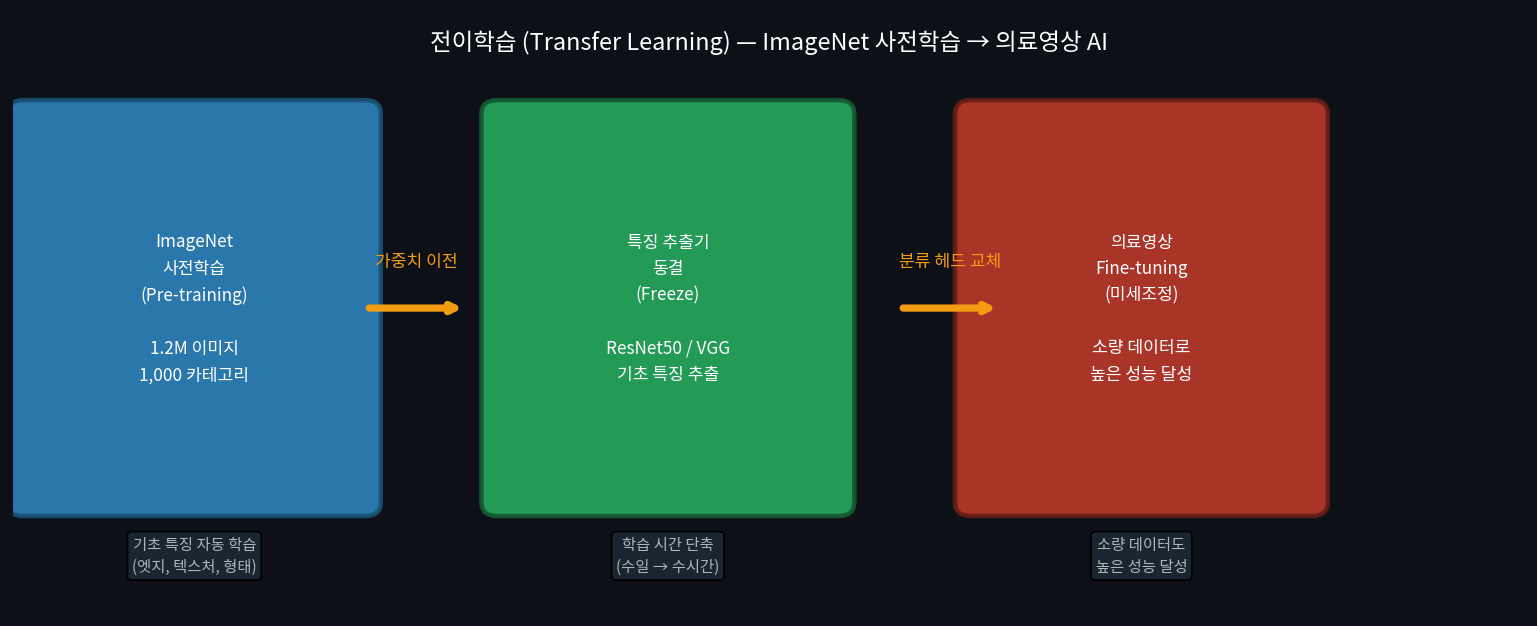

<sub><b>그림 4-1. 전이학습(Transfer Learning) 흐름도 — ImageNet → 의료영상 AI</b></sub>

</div>

In [ ]:
# ─────────────────────────────────────────────────────
#  🚀 프로젝트 1: 전이학습(Transfer Learning) 개념 시연
# ─────────────────────────────────────────────────────

if TF_AVAILABLE:
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.layers import GlobalAveragePooling2D

    print('📦 ResNet50 모델 (ImageNet 사전학습 가중치) 로드 중...')
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # 기존 가중치 동결

    # 커스텀 분류 헤드 추가
    breast_cancer_model = models.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # 이진 분류
    ], name='BreastCancer_ResNet50')

    breast_cancer_model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Recall(name='recall')]
    )

    print('\n🏗️  유방암 분류 모델 구조:')
    breast_cancer_model.summary()
    print('\n✅ 전이학습 모델 준비 완료!')
    print(f'   동결된 파라미터: {sum(~v.trainable for v in base_model.variables):,}개')
    print(f'   학습 가능 파라미터: {breast_cancer_model.count_params() - base_model.count_params():,}개')
    print('\n💡 전이학습의 장점:')
    print('   - ImageNet 가중치로 기초 특징(엣지, 텍스처) 이미 학습됨')
    print('   - 적은 의료 데이터로도 높은 성능 달성 가능')
    print('   - 학습 시간 대폭 단축')
else:
    print('TensorFlow 설치 후 실행하세요.')

In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 8: 전이학습 개념도 & 데이터 증강 예시
# ─────────────────────────────────────────────────────

# 모의 조직 이미지 생성
def make_tissue_image(cancer=False, seed=0):
    np.random.seed(seed)
    img = np.zeros((128, 128, 3), dtype=np.float32)
    # 세포 배경
    for _ in range(200):
        cx, cy = np.random.randint(0, 128, 2)
        r = np.random.randint(3, 8)
        color = [0.7 + 0.2*np.random.rand(), 0.5 + 0.3*np.random.rand(), 0.7 + 0.2*np.random.rand()]
        for rr in range(max(0,cy-r), min(128,cy+r)):
            for cc in range(max(0,cx-r), min(128,cx+r)):
                if np.sqrt((rr-cy)**2 + (cc-cx)**2) < r:
                    img[rr, cc] = color
    if cancer:
        # 비정상 세포 (크고 불규칙)
        for _ in range(30):
            cx, cy = np.random.randint(20, 108, 2)
            r = np.random.randint(8, 15)
            for rr in range(max(0,cy-r), min(128,cy+r)):
                for cc in range(max(0,cx-r), min(128,cx+r)):
                    if np.sqrt(((rr-cy)/np.random.uniform(0.8,1.2))**2 +
                               ((cc-cx)/np.random.uniform(0.8,1.2))**2) < r:
                        img[rr, cc] = [0.9*np.random.rand(), 0.1, 0.2*np.random.rand()]
    return np.clip(img, 0, 1)

normal_img = make_tissue_image(cancer=False, seed=1)
cancer_img = make_tissue_image(cancer=True,  seed=3)

# 데이터 증강 시뮬레이션
def augment_image(img):
    img_uint8 = (img * 255).astype(np.uint8)
    augs = {}
    augs['원본'] = img
    augs['수평 뒤집기'] = np.flip(img, axis=1)
    augs['수직 뒤집기'] = np.flip(img, axis=0)
    M = cv2.getRotationMatrix2D((64, 64), 30, 1.0)
    rotated = cv2.warpAffine(img_uint8, M, (128, 128)).astype(np.float32) / 255
    augs['30° 회전'] = rotated
    bright = np.clip(img * 1.4, 0, 1)
    augs['밝기 증가 (+40%)'] = bright
    noise = np.clip(img + np.random.normal(0, 0.05, img.shape), 0, 1)
    augs['가우시안 노이즈'] = noise
    return augs

augmented = augment_image(normal_img)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('프로젝트 1: 유방암 조직 분류 — 데이터 시각화', fontsize=13, fontweight='bold')

# 상단: 정상 vs 암성
axes[0, 0].imshow(normal_img)
axes[0, 0].set_title('✅ 정상 조직\n(작고 균일한 세포)', fontsize=10, color='green')
axes[0, 0].axis('off')
axes[0, 1].imshow(cancer_img)
axes[0, 1].set_title('❌ 암성 조직\n(크고 불규칙한 세포)', fontsize=10, color='red')
axes[0, 1].axis('off')

# 빈 셀
for i in range(2, 6):
    axes[0, i].axis('off')

# 데이터 증강 설명 박스
axes[0, 2].text(0.1, 0.6,
    '데이터 증강 (Data Augmentation)\n\n'
    '왜 필요한가?\n'
    '• 의료 데이터는 매우 부족\n'
    '• 다양한 변형으로 학습 강화\n'
    '• 과적합 방지\n\n'
    '일반적 기법:\n'
    '• 뒤집기(Flip)\n'
    '• 회전(Rotation)\n'
    '• 밝기/대비 조정\n'
    '• 확대/축소(Zoom)',
    transform=axes[0, 2].transAxes,
    fontsize=9, va='top',
    bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.9))

# 하단: 증강 예시
for ax, (name, aug_img) in zip(axes[1], augmented.items()):
    ax.imshow(aug_img)
    ax.set_title(name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('fig11_project1.png', bbox_inches='tight')
plt.show()

## 프로젝트 2: 흉부 X-ray 이미지 분할 (U-Net)

**목표**: 흉부 X-ray에서 폐 영역 자동 분할  
**모델**: U-Net (의료영상 분할의 표준)

<div align="center">

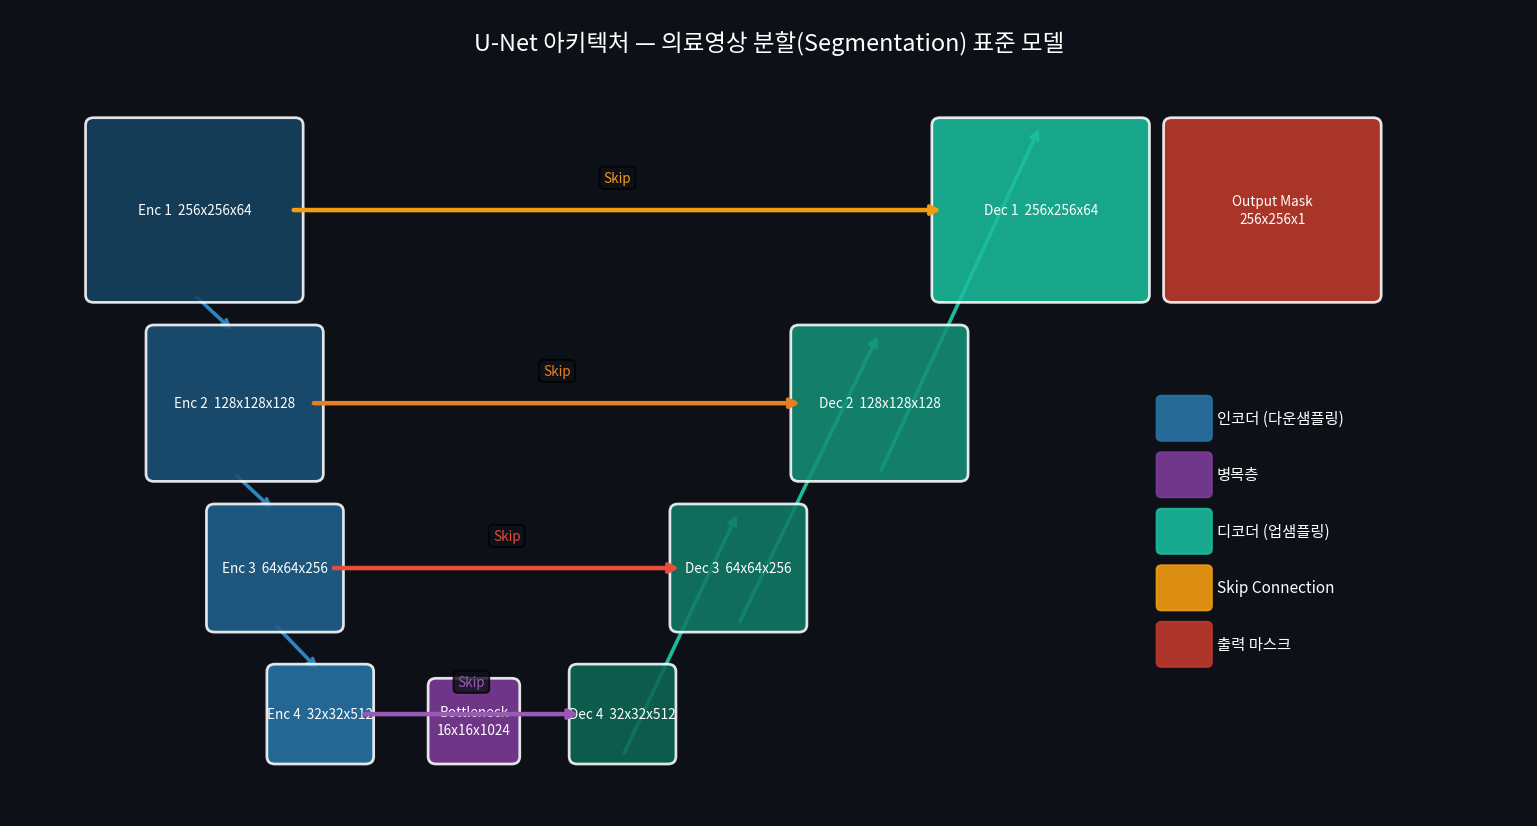

<sub><b>그림 4-2. U-Net 인코더-디코더 아키텍처와 Skip Connection</b></sub>

</div>

In [ ]:
# ─────────────────────────────────────────────────────
#  🚀 프로젝트 2: U-Net 아키텍처 구현
# ─────────────────────────────────────────────────────

if TF_AVAILABLE:
    def unet_conv_block(x, filters, name=''):
        """U-Net 기본 빌딩 블록"""
        x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{name}_c1')(x)
        x = layers.BatchNormalization(name=f'{name}_bn1')(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu', name=f'{name}_c2')(x)
        x = layers.BatchNormalization(name=f'{name}_bn2')(x)
        return x

    def build_unet(input_shape=(256, 256, 1), n_classes=1):
        """U-Net 모델 (인코더-디코더 구조)"""
        inputs = keras.Input(shape=input_shape, name='input')

        # ── 인코더 (수축 경로) ──
        c1 = unet_conv_block(inputs, 64,  'enc1')
        p1 = layers.MaxPooling2D(2, name='pool1')(c1)

        c2 = unet_conv_block(p1, 128, 'enc2')
        p2 = layers.MaxPooling2D(2, name='pool2')(c2)

        c3 = unet_conv_block(p2, 256, 'enc3')
        p3 = layers.MaxPooling2D(2, name='pool3')(c3)

        # ── 병목 (Bottleneck) ──
        c4 = unet_conv_block(p3, 512, 'bottleneck')

        # ── 디코더 (확장 경로) + Skip Connections ──
        u5 = layers.UpSampling2D(2, name='up1')(c4)
        u5 = layers.Concatenate(name='skip3')([u5, c3])  # Skip!
        c5 = unet_conv_block(u5, 256, 'dec3')

        u6 = layers.UpSampling2D(2, name='up2')(c5)
        u6 = layers.Concatenate(name='skip2')([u6, c2])  # Skip!
        c6 = unet_conv_block(u6, 128, 'dec2')

        u7 = layers.UpSampling2D(2, name='up3')(c6)
        u7 = layers.Concatenate(name='skip1')([u7, c1])  # Skip!
        c7 = unet_conv_block(u7, 64, 'dec1')

        # ── 출력 ──
        outputs = layers.Conv2D(n_classes, 1, activation='sigmoid', name='output')(c7)

        return keras.Model(inputs, outputs, name='U-Net_Lung_Segmentation')

    unet = build_unet(input_shape=(256, 256, 1))
    unet.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    print('🏗️  U-Net 모델 구조:')
    unet.summary()
    print(f'\n총 파라미터: {unet.count_params():,}개')
else:
    print('TensorFlow 설치 후 실행하세요.')

In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 9: U-Net 분할 결과 시뮬레이션
# ─────────────────────────────────────────────────────

# 합성 흉부 X-ray + 폐 마스크 생성
def make_chest_xray(size=256):
    img  = np.zeros((size, size), dtype=np.float32)
    mask = np.zeros((size, size), dtype=np.float32)
    cx, cy = size//2, size//2
    # 흉곽
    for r in range(size):
        for c in range(size):
            d = np.sqrt(((r-cy)/1.3)**2 + (c-cx)**2)
            if 88 < d < 102:
                img[r, c] = 0.85
            elif d < 88:
                img[r, c] = 0.2
    # 심장
    for r in range(size):
        for c in range(size):
            if np.sqrt(((r-cy+5)/1.1)**2 + ((c-cx+8)/0.8)**2) < 28:
                img[r, c] = 0.65
    # 폐 좌우
    for lx, lsign in [(cx-38, -1), (cx+38, 1)]:
        for r in range(size):
            for c in range(size):
                if np.sqrt(((r-cy+8)/1.4)**2 + (c-lx)**2) < 38:
                    img[r, c]  = 0.05 + 0.08*np.random.rand()
                    mask[r, c] = 1.0
    img  = cv2.GaussianBlur(img, (3,3), 0)
    img += np.random.normal(0, 0.025, img.shape)
    return np.clip(img, 0, 1), mask

np.random.seed(5)
chest, true_mask = make_chest_xray(256)

# 예측 마스크 시뮬레이션 (살짝 불완전하게)
pred_mask = true_mask.copy()
pred_mask += np.random.normal(0, 0.12, pred_mask.shape)
pred_mask = np.clip(pred_mask, 0, 1)
pred_binary = (pred_mask > 0.45).astype(np.float32)

# Dice Score 계산
intersection = (pred_binary * true_mask).sum()
dice = 2 * intersection / (pred_binary.sum() + true_mask.sum())

# 시각화
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('프로젝트 2: U-Net 폐 영역 분할 결과', fontsize=13, fontweight='bold')

axes[0].imshow(chest, cmap='bone')
axes[0].set_title('① 원본 X-ray', fontsize=11)
axes[0].axis('off')

axes[1].imshow(true_mask, cmap='gray')
axes[1].set_title('② Ground Truth\n(전문가 수동 주석)', fontsize=11)
axes[1].axis('off')

axes[2].imshow(pred_binary, cmap='gray')
axes[2].set_title(f'③ U-Net 예측\n(Dice: {dice:.3f})', fontsize=11)
axes[2].axis('off')

# 오버레이
overlay = np.stack([chest, chest, chest], axis=-1)
overlay[:,:,0] = np.where(pred_binary > 0, 0.8, chest)
overlay[:,:,1] = np.where(true_mask  > 0, 0.8, chest)
overlay[:,:,2] = chest
axes[3].imshow(overlay)
axes[3].set_title('④ 비교 오버레이\n빨강=예측만, 녹색=정답만, 노랑=일치', fontsize=11)
axes[3].axis('off')

# Dice Score 설명
axes[4].axis('off')
axes[4].text(0.05, 0.95,
    f'평가 지표\n'
    f'━━━━━━━━━━━━━\n'
    f'Dice Score: {dice:.3f}\n'
    f'(1.0 = 완벽한 분할)\n\n'
    f'Dice Formula:\n'
    f'2|A∩B| / (|A|+|B|)\n\n'
    f'A = 예측 마스크\n'
    f'B = 정답 마스크\n\n'
    f'임상 목표: Dice > 0.90\n'
    f'현재 달성: {"✅" if dice > 0.85 else "⚠️"}',
    transform=axes[4].transAxes,
    fontsize=10, va='top',
    bbox=dict(boxstyle='round', facecolor='#e8f8f5', alpha=0.9)
)

plt.tight_layout()
plt.savefig('fig12_unet.png', bbox_inches='tight')
plt.show()
print(f'\n💡 Dice Score {dice:.3f}은 두 영역의 겹침 정도를 나타냅니다 (1이 최대)!')

## 프로젝트 3: 이상탐지 (Anomaly Detection)

**목표**: CT 스캔에서 비정상 패턴 자동 감지  
**기법**: Autoencoder (정상 영상으로만 학습 → 이상은 재구성 오차 커짐)

In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 10: Autoencoder 이상탐지 개념 시뮬레이션
# ─────────────────────────────────────────────────────

def make_ct_slice(anomaly=False, anomaly_pos=None, seed=0):
    """모의 CT 슬라이스 생성"""
    np.random.seed(seed)
    size = 128
    img = np.zeros((size, size))
    cx, cy = 64, 64
    # 몸통
    for r in range(size):
        for c in range(size):
            d = np.sqrt(((r-cy)/1.2)**2 + (c-cx)**2)
            if d < 52:
                img[r, c] = 0.35 + 0.1*np.random.rand()
            if d < 50:
                img[r, c] = 0.3
    # 척추
    img[50:80, 60:68] = 0.88
    # 폐
    for lx in [40, 88]:
        for r in range(size):
            for c in range(size):
                if np.sqrt((r-56)**2 + (c-lx)**2) < 22:
                    img[r, c] = 0.05
    # 이상 (종양 시뮬레이션)
    if anomaly:
        ax_pos = anomaly_pos or (65, 44)
        for r in range(size):
            for c in range(size):
                d = np.sqrt((r-ax_pos[0])**2 + (c-ax_pos[1])**2)
                if d < 9:
                    img[r, c] = 0.82 - 0.2*(d/9)
    img += np.random.normal(0, 0.015, img.shape)
    return np.clip(img, 0, 1)

# 정상 vs 이상 CT 이미지
normal_ct = make_ct_slice(anomaly=False, seed=0)
anomaly_ct = make_ct_slice(anomaly=True,  anomaly_pos=(58, 45), seed=1)

# Autoencoder 재구성 시뮬레이션
def simulate_reconstruction(img, is_anomaly=False):
    """Autoencoder 재구성 시뮬레이션"""
    recon = cv2.GaussianBlur(img, (5, 5), 1.5)
    if is_anomaly:
        # 비정상 영역은 재구성이 잘 안 됨 → 오차 큼
        for r in range(128):
            for c in range(128):
                if np.sqrt((r-58)**2 + (c-45)**2) < 10:
                    recon[r, c] += 0.4 * np.random.rand()
    return np.clip(recon, 0, 1)

recon_normal  = simulate_reconstruction(normal_ct,  is_anomaly=False)
recon_anomaly = simulate_reconstruction(anomaly_ct, is_anomaly=True)

# 재구성 오차 맵
error_normal  = np.abs(normal_ct  - recon_normal)
error_anomaly = np.abs(anomaly_ct - recon_anomaly)

# 시각화
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('프로젝트 3: Autoencoder 이상탐지 — 재구성 오차로 병변 감지',
             fontsize=13, fontweight='bold')

row_labels = ['정상 CT', '이상 CT\n(종양 포함)']
col_labels = ['원본 이미지', 'Autoencoder 재구성', '재구성 오차 맵', '이상 탐지 결과']

for row, (orig, recon, error, is_anom) in enumerate([
    (normal_ct,  recon_normal,  error_normal,  False),
    (anomaly_ct, recon_anomaly, error_anomaly, True)
]):
    threshold = 0.15
    detected = (error > threshold).astype(float)

    axes[row, 0].imshow(orig, cmap='gray')
    axes[row, 0].set_title(f'{col_labels[0]}\n({row_labels[row]})', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(recon, cmap='gray')
    axes[row, 1].set_title(col_labels[1], fontsize=9)
    axes[row, 1].axis('off')

    im = axes[row, 2].imshow(error, cmap='hot', vmin=0, vmax=0.4)
    axes[row, 2].set_title(f'{col_labels[2]}\n평균 오차: {error.mean():.4f}', fontsize=9)
    axes[row, 2].axis('off')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)

    # 탐지 오버레이
    ov = np.stack([orig, orig, orig], axis=-1)
    if is_anom:
        ov[:,:,0] = np.where(detected > 0, 1.0, orig)
        ov[:,:,1] = np.where(detected > 0, 0.1, orig)
        ov[:,:,2] = np.where(detected > 0, 0.1, orig)
        status = '⚠️ 이상 탐지!'
    else:
        status = '✅ 정상'
    axes[row, 3].imshow(ov)
    axes[row, 3].set_title(f'{col_labels[3]}\n{status}', fontsize=9,
                           color='red' if is_anom else 'green')
    axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('fig13_anomaly.png', bbox_inches='tight')
plt.show()
print('\n💡 Autoencoder는 정상 패턴만 학습하므로 비정상 입력은 재구성이 잘 안 됩니다!')

---
# 📚 학습 로드맵 및 정리

## 권장 학습 순서 (24주 커리큘럼)

| 주차 | 내용 | 목표 |
|------|------|------|
| **1~2주** | Python 기초, NumPy, Matplotlib | 코딩 기초 |
| **3~4주** | 의료영상 기초 이론, OpenCV | 영상처리 이해 |
| **5~6주** | 머신러닝 기초, scikit-learn | ML 기초 |
| **7~10주** | 딥러닝 기초, TensorFlow/Keras | DL 실습 |
| **11~16주** | 프로젝트 1 (유방암 분류) | 전이학습 |
| **17~22주** | 프로젝트 2~3 (분할/탐지) | U-Net, AE |
| **23~24주** | 최종 발표 및 평가 | 종합 |

## 추천 학습 자료

- 📹 **강좌**: Coursera "Convolutional Neural Networks for Medical Image Analysis"
- 📄 **논문**: "U-Net: Convolutional Networks for Biomedical Image Segmentation" (Ronneberger et al., 2015)
- 📚 **책**: "Deep Learning in Medical Image Analysis" (Elsevier)
- 🛠️ **오픈소스**: MONAI (Medical Open Network for AI)
- 📊 **데이터셋**: MICCAI Challenge, CheXpert, NIH Chest X-ray

In [ ]:
# ─────────────────────────────────────────────────────
#  📊 시각화 11: 학습 로드맵 시각화
# ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(0, 24)
ax.set_ylim(-1, 6)
ax.axis('off')
ax.set_title('의료영상 AI 24주 학습 로드맵', fontsize=15, fontweight='bold', pad=15)

phases = [
    (0,  2,  '1~2주\nPython 기초\nNumPy/Matplotlib', '#3498db', '🐍'),
    (2,  4,  '3~4주\n의료영상 이론\nOpenCV',          '#2ecc71', '🔬'),
    (4,  6,  '5~6주\nML 기초\nscikit-learn',         '#e67e22', '🤖'),
    (6,  10, '7~10주\n딥러닝 기초\nTF/Keras',         '#9b59b6', '🧠'),
    (10, 16, '11~16주\n프로젝트 1\n유방암 분류',       '#e74c3c', '🏥'),
    (16, 22, '17~22주\n프로젝트 2~3\n분할/탐지',       '#1abc9c', '🔍'),
    (22, 24, '23~24주\n최종 발표\n& 평가',             '#f39c12', '🎓'),
]

for i, (start, end, label, color, emoji) in enumerate(phases):
    width = end - start - 0.15
    rect = patches.FancyBboxPatch((start + 0.075, 1.5), width, 2,
                                   boxstyle='round,pad=0.1',
                                   facecolor=color, alpha=0.85,
                                   edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text((start + end)/2, 2.5, emoji, ha='center', va='center', fontsize=20)
    ax.text((start + end)/2, 1.8, label, ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold')

# 화살표 타임라인
ax.annotate('', xy=(23.5, 0.8), xytext=(0.5, 0.8),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
for w in range(0, 25, 2):
    ax.text(w, 0.4, f'{w}주', ha='center', fontsize=8.5, color='gray')

# 능력치 향상 곡선
skill_weeks = [0, 2, 4, 6, 10, 16, 22, 24]
skill_level = [0, 1, 2, 3, 5, 7, 9, 10]
ax2 = ax.twinx()
ax2.set_ylim(-1, 6)
ax2.plot([w for w in skill_weeks], [s*0.45+4.0 for s in skill_level],
         'w--', lw=2, alpha=0.6, label='실력 향상')
ax2.axis('off')
ax.text(12, 4.8, '─── 실력 향상 곡선', fontsize=9, color='white', alpha=0.8)

plt.tight_layout()
plt.savefig('fig14_roadmap.png', bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────
#  ✅ 실습 숙제 체크리스트
# ─────────────────────────────────────────────────────

homework = {
    '기초 Python 실습': [
        'NumPy 배열의 shape, reshape 이해하기',
        '정규화 방법 3가지(MinMax, ZScore, 8bit) 비교',
        'OpenCV 필터 5가지 효과 시각화',
    ],
    '데이터 전처리': [
        '이진화 3방법 비교 (단순, 적응형, Otsu)',
        '데이터 증강 6기법 코드로 구현',
        'CLAHE vs 히스토그램균등화 차이 분석',
    ],
    '모델 구축 & 학습': [
        'Dense 네트워크 vs CNN 성능 비교',
        '활성화함수 4종 (ReLU/Sigmoid/Tanh/LeakyReLU) 비교',
        'Dropout 비율 변화 실험 (0.0, 0.2, 0.5, 0.8)',
    ],
    '하이퍼파라미터 튜닝': [
        '학습률 변경 영향 분석 (1e-2, 1e-3, 1e-4)',
        '배치 크기 변경 실험 (16, 32, 64, 128)',
        '에포크 vs 검증 손실 관계 그래프',
    ],
    '최종 프로젝트': [
        '공개 의료영상 데이터셋 1개 선택 (CheXpert, NIH 등)',
        '전이학습으로 분류/분할 모델 구현',
        '성능 지표 종합 분석 (Acc, AUC, Recall, Dice)',
    ],
}

print('=' * 60)
print('  📝 실습 숙제 체크리스트')
print('=' * 60)
total = 0
for category, tasks in homework.items():
    print(f'\n🗂️  {category}')
    for i, task in enumerate(tasks, 1):
        print(f'  [ ] {i}. {task}')
        total += 1
print(f'\n총 {total}개 항목 — 모두 완료하면 의료 AI 기초 마스터! 🎓')

---

## 🎉 수고하셨습니다!

이 노트북에서 다룬 내용 요약:

✅ **Part 1** — X-ray, CT, MRI, 초음파, PET 기법 및 처리 파이프라인  
✅ **Part 2** — 딥러닝 핵심 개념, CNN 구조, AI 작업 유형  
✅ **Part 3** — NumPy·OpenCV 실습, SVM 분류, CNN 학습, 성능 평가  
✅ **Part 4** — 유방암 분류(ResNet), 폐 분할(U-Net), 이상탐지(Autoencoder)  

---

> 💬 **궁금한 점**이 있으면 주저하지 말고 질문하세요.  
> 의료 AI는 **환자의 생명**과 직결되는 중요한 분야입니다. 끝까지 파이팅! 🏥